### Introduction

Leakage is where a qubit leaves the computational subspace of |0⟩ and |1⟩ and occupies, or is in a superposition with, another energy level, call it |2⟩. 

Leakage is modelled here using the [depolarising leakage model](10.1088/1367-2630/ab3372) where the a leaked qubit maximally depolarises and any qubit it subsequently interacts with also maximally depolarises.

- *BEST NOT to mix [deltakit](https://github.com/Deltakit/deltakit) with [deltakit stim](https://github.com/Deltakit/deltakit-stim). Despite the deltakit stim README pointing to deltakit, there are lots of clashes that arise if you do so and it seems like deltakit stim is standalone*.

- [Deltakit stim](https://github.com/Deltakit/deltakit-stim) is a fork of stim which adds the functionality to simulate leakage. It has four additional [operations](https://github.com/Deltakit/deltakit-stim/blob/main/doc/deltakit_stim_gates.md):

    - `LEAKAGE`
        • depolarising leakage. Convert this qubit to the maximally depolarised state if it leaks. Also, any future qubits this qubit interacts with also get fully depolarised.
        • (Future work: could look into the docs to make less harmful leakage model, like Mølmer-Sørensen leakage as per Brown's papers)
        • Reset gates return leaked qubits to the computational subspace

    - `RELAX`
        • Relaxes a leaked qubit back to the maximally depolarised state (which was done with the LEAKAGE instruction) with a given probability. Otherwise does nothing. Once the qubit is relaxed it no longer depolarises qubits it interacts with (it will just transmit errors normally from being a maximally depolarised state)

    - `HERALD_LEAKAGE_EVENT`
        - This is the herald. It heralds / tells you whether a qubit is leaked or not. Consider it a leakage-detecting measurement. It populates the measurement record with this data.
        - Can use this just in front of measurements to simulate a measurement that also detects leakage.
        - Note that Deltakit's leakage model is NOT contagious leakage. A leaked qubit does not cause another to leak, simply to maximally depolarize.
        - So can't be used for loss, which IS contagious in ion traps (walking cat paper explains that trying to merge the coulomb potentials of an ion with another that isn't there results in the loss of the first ion), unless of course you model what the walking cat paper does which is a beacon qubit measurment after every two-qubit gate, then you always know if a qubit is lost. 

    - `RL`
        - Relaxes target qubit into the computational subspace (where it is maximally depolarised). Seems to be equivalent to `RELAX(1)`



<br>

- We work through examples here. Can also see some circuit examples at:
  - https://github.com/Deltakit/deltakit-stim

##### Imports

In [2]:
import sys
import deltakit_stim as stim
injections = ['stim._detect_machine_architecture', 'stim._stim_polyfill', 'stim']
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]

### New operations

error(0.5) D0 D1
Notice the DEM has a conditional probability now, the underlying probability of the leakage itself is determined by sampling the circuit, so in the DEM is just the conditional probability P(D1 | D0). That is, when D0 fires (indicating leakage), D1 also fires 50% of the time.

Number of |1⟩ measurements (indicating X or Y errors from DEP noise):
104/1000


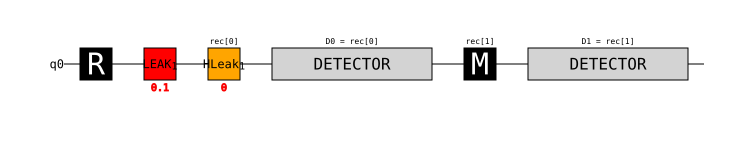

In [55]:
# A circuit with guaranteed leakage. When a qubit leaks it is sent the the fully depolarised state. One way to simulate this (and how deltakit does it) is applying an X error with 50% followed by a Z error with 50%. This results in 1/4 chance for each of I, X, Y, Z. Over many samples, this is equivalent to the state being in the maximally depolarised state.

circuit = stim.Circuit("""
R 0
LEAKAGE(0.1) 0
HERALD_LEAKAGE_EVENT() 0 
DETECTOR rec[-1]
M 0
DETECTOR rec[-1]
""")

measurement_detector = 0 # is the measurement detector the 0th, 1st, 2nd etc. detector in the circuit


sampler_object = circuit.compile_detector_sampler()
# Run the circuit and show the measurement result. As we are measuring in the Z basis we will only see X or Y errors, which happen 50% of the time.
num_shots = 1000
print(circuit.detector_error_model())
print("Notice the DEM has a conditional probability now, the underlying probability of the leakage itself is determined by sampling the circuit, so in the DEM is just the conditional probability P(D1 | D0). That is, when D0 fires (indicating leakage), D1 also fires 50% of the time.\n")

print(f"Number of |1⟩ measurements (indicating X or Y errors from DEP noise):")
print(f"{sum(sampler_object.sample(shots = num_shots))[measurement_detector]}/{num_shots}")
# circuit.diagram("matchgraph-3d")
circuit.diagram("timeline-svg")


error(0.5) D0 D1


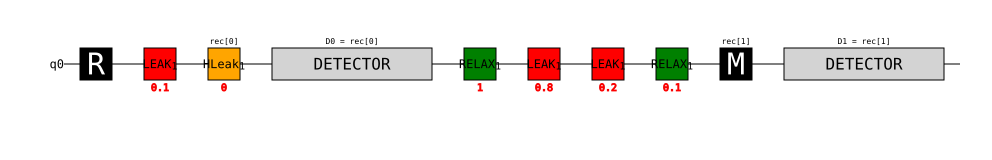

In [56]:
# A circuit with guaranteed leakage. When a qubit leaks it is sent the the fully depolarised state. One way to simulate this (and how deltakit does it) is applying an X error with 50% followed by a Z error with 50%. This results in 1/4 chance for each of I, X, Y, Z. Over many samples, this is equivalent to the state being in the maximally depolarised state.

circuit = stim.Circuit("""
R 0
LEAKAGE(0.1) 0
HERALD_LEAKAGE_EVENT() 0 
DETECTOR rec[-1]
RELAX(1) 0
LEAKAGE(0.8) 0
LEAKAGE(0.2) 0
RELAX(0.1) 0
M 0
DETECTOR rec[-1]
""")


print(circuit.detector_error_model())
circuit.diagram("timeline-svg")


In [3]:
# CX gate and a measurement that can detect leakage has a HERALD_LEAKAGE_EVENT() attached to it

circuit = stim.Circuit("""
R 0 1
LEAKAGE(1) 0  # guaranteed leakage (p = 1)
CX 0 1
TICK
HERALD_LEAKAGE_EVENT() 0 1 # No argument in parenthesis means it detects leakage accurately. An argument (e.g. 0.3) means it fails with that probability
M 0 1
""")

sampler_object = circuit.compile_sampler()

# Run the circuit and show the measurement results.
num_shots = 10
print("First two elements are the measurement results of herald_leakage_event,\nsecond two are the measurements in the Z basis (flipped by X or Y errors):\n")
print(sum(sampler_object.sample(shots = num_shots)))
print("\nWe note that the first qubit leaks 10/10 times. They then each have an independent\n50% chance of having an X or Y error, flipping their Z measurement.\nLeakage is not contagious. The other qubit gets fully depolarised but does\nnot leak, which would affect subsequent qubits that it interacts with.\nThis is the depolarising leakage model in Natalie Brown's papers:\n10.1103/physreva.100.032325, 10.1088/1367-2630/ab3372")
# display(circuit.diagram("timeline-svg"))


First two elements are the measurement results of herald_leakage_event,
second two are the measurements in the Z basis (flipped by X or Y errors):

[10  0  4  5]

We note that the first qubit leaks 10/10 times. They then each have an independent
50% chance of having an X or Y error, flipping their Z measurement.
Leakage is not contagious. The other qubit gets fully depolarised but does
not leak, which would affect subsequent qubits that it interacts with.
This is the depolarising leakage model in Natalie Brown's papers:
10.1103/physreva.100.032325, 10.1088/1367-2630/ab3372


[ 0 10  6  6]


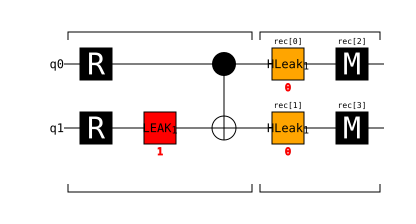

In [4]:
# CX gate target to control leakage? -- yes.

circuit = stim.Circuit("""
R 0 1
LEAKAGE(1) 1  # guaranteed leakage (p = 1)
CX 0 1
TICK
HERALD_LEAKAGE_EVENT() 0 1 # No argument in parenthesis means it detects leakage accurately. An argument (e.g. 0.3) means it fails with that probability
M 0 1
""")

sampler_object = circuit.compile_sampler()

# Run the circuit and show the measurement results.
num_shots = 10

print(sum(sampler_object.sample(shots = num_shots)))
display(circuit.diagram("timeline-svg"))


In [ ]:
circuit = stim.Circuit('''
R 0 1
LEAKAGE(0.05) 1
CX 0 1
M 0 1
HERALD_LEAKAGE_EVENT() 0 1
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
''')



In [9]:
import deltakit_stim
circuit = deltakit_stim.Circuit("""
    R 0 
    X_ERROR(0.001) 0
    M 0
    DETECTOR rec[-1]""")
print(circuit.detector_error_model())

error(0.001) D0

error(0.001) D0


error(0.1) D1
detector D0


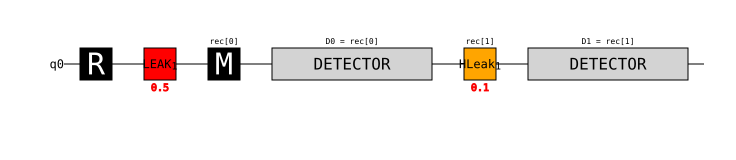

In [10]:
import deltakit_stim

leaky_circuit = deltakit_stim.Circuit("""
    R 0 
    LEAKAGE(0.5) 0
    M 0
    DETECTOR rec[-1]
    HERALD_LEAKAGE_EVENT(0.1) 0
    DETECTOR rec[-1]
    """)

print(leaky_circuit.detector_error_model())
display(leaky_circuit.diagram('timeline-svg'))

In [6]:
# CHECKING THE RELAX GATE:
# It is equivalent to just apply a maximally depolarising channel or leak and immediately relax a qubit.

# The RELAX gate stops the qubit being leaked -- so it will no longer depolarize qubits it interacts with. Note though that it has been returned to the maximally depolarised state.
# Consequently, either including choice 1 (leakage and relax) OR choice 2 (depolarize(0.75), where p = 0.75 means 1/4 prob of each I, X, Y, Z which is p = 1 of converting to maximally depolarised state) in the circuit below gives the same outcomes: correlated measurements on the two qubits (both 1 50% of the time as this means an X or Y error occurred on the first qubit as was transferred through the CNOT).

# Only including leakage and no relax means maximally depolarize the first qubit which then maximally depolarizes the second qubit - so both have 50% chance of measuring 1 but will not be exactly correlated.

circuit = stim.Circuit("""
R 0 1

LEAKAGE(1) 0 # Choice 1
RELAX(1) 0   # Choice 1

# DEPOLARIZE1(0.75) 0  # Choice2 

CX 0 1
M 0 1
""")

# Run the circuit and show the measurement results.
samples = circuit.compile_sampler().sample(100)

print(f"M0: {sum(samples)[0]}/{num_shots}")
print(f"M1: {sum(samples)[1]}/{num_shots}")

# circuit.diagram("timeline-svg")

M0: 55/10
M1: 55/10


rec[0]: 0/100
rec[1]: 44/100


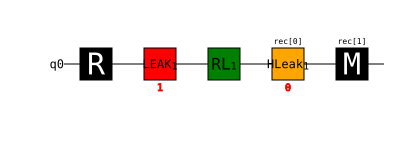

In [7]:
# The RL gate is just RELAX(p=1)

circuit = stim.Circuit("""
R 0
LEAKAGE(1) 0
# R 0  ## Resetting actually puts it to |0⟩
RL 0   ## Leakage reset seems to be RELAX(p=1), i.e. not leaked anymore but is still maximally depolarised state
HERALD_LEAKAGE_EVENT() 0
M 0 
""")

sampler_object = circuit.compile_sampler()
num_shots = 100
samples = sampler_object.sample(shots = num_shots)
print(f"rec[0]: {sum(samples)[0]}/{num_shots}")
print(f"rec[1]: {sum(samples)[1]}/{num_shots}")

circuit.diagram("timeline-svg")


In [8]:
# Can append instructions too:

circ = stim.Circuit()
circ.append("RZ", [0, 1],)
circ.append("LEAKAGE", [0, 1], 0.1)
circ.append("RELAX", 0, 0.1)
circ.append("M", [0, 1], 0.1)
circ.append("HERALD_LEAKAGE_EVENT", [0, 1], 0.1)
circ.append("RL", 0)
print(circ)

R 0 1
LEAKAGE(0.1) 0 1
RELAX(0.1) 0
M(0.1) 0 1
HERALD_LEAKAGE_EVENT(0.1) 0 1
RL 0


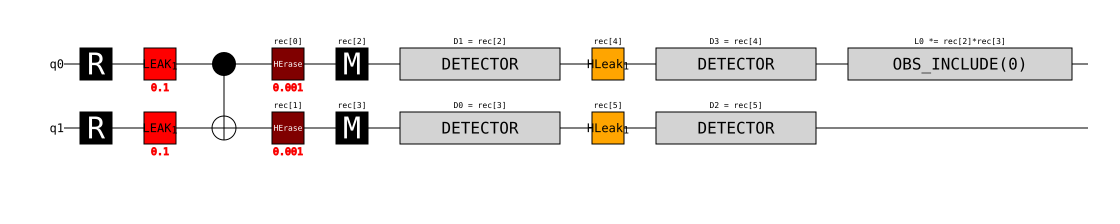

In [40]:
circuit = deltakit_stim.Circuit("""
R 0 1
LEAKAGE(0.1) 0 1
CNOT 0 1
HERALDED_ERASE(0.001) 0 1
M 0 1
DETECTOR rec[-1]
DETECTOR rec[-2]
HERALD_LEAKAGE_EVENT 0 1
DETECTOR rec[-1]
DETECTOR rec[-2]
OBSERVABLE_INCLUDE(0) rec[-4] rec[-3]
""")

circuit.diagram("timeline-svg")

num_heralds =  56
num_ones_measured =  36


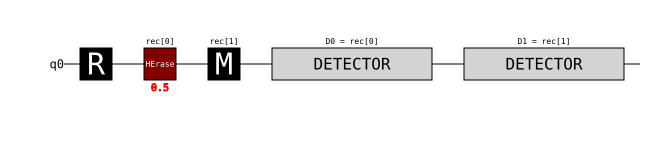


Detector Error Model:
error(0.25) D0
error(0.25) D0 D1


In [ ]:
import deltakit_stim as stim

# Getting detection events:
circuit = stim.Circuit("""
R 0
LEAKAGE(0.8) 0
HERALDED_ERASE(0.5) 0
M 0
HERALD_LEAKAGE_EVENT 0
# DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
""")

sampler = circuit.compile_detector_sampler()
detection_events = sampler.sample(shots=100)

# print(detection_events) # Each row is a new sample. Along each row is the subsequent detectors. Num_detectors = num_columns

heralds = detection_events[:,0]
num_heralds = sum(heralds)

print(f"num_heralds = ",num_heralds)
print(f"num_ones_measured = ", sum(detection_events[:,1]))
display(circuit.diagram("timeline-svg"))
# Generate the DEM to see the heralded errors
dem = circuit.detector_error_model(approximate_disjoint_errors=True)
print(f"\nDetector Error Model:\n{dem}")

In [10]:
## With observables:
## DELTAKIT STIM ##
import deltakit_stim
# Deltakit circuit clashes with deltakit_stim unless do these injections
injections = ['stim._detect_machine_architecture', 'stim._stim_polyfill', 'stim']
import sys
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]


circuit = deltakit_stim.Circuit("""
R 0
LEAKAGE(1) 0
HERALD_LEAKAGE_EVENT 0
M 0
DETECTOR rec[-2]
DETECTOR rec[-1]
OBSERVABLE_INCLUDE(0) rec[-1]
""")

sampler = circuit.compile_detector_sampler()
detection_events, observables = sampler.sample(shots=10, separate_observables = True) # gives two arrays. One with the detection events per shot. One with the observables per shot.

# print(detection_events) # Each row is a new sample. Along each row is the subsequent detectors.
# print(observables)